# FoundationStereo 2448 × 2048 离线推理

从 `data/<timestamp>/left.png`、`right.png`、`masks/left_mask.png` 与 `calibration.json` 读取一组原始双目图像。掩码与原始左图对齐，使用相同的左图 rectification map 重映射后用于筛选点云。先运行模型加载单元一次；切换数据时只需要重跑数据、推理和导出单元。不会创建 Open3D 可视化窗口。

## 1. 环境与共用工具

In [1]:
from pathlib import Path
import json, sys, time
import cv2
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
import torch
from omegaconf import OmegaConf

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in (cwd, *cwd.parents) if (p / 'FoundationStereo').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('请从 FS_realsense 或其子目录启动 notebook。')
FS_ROOT = REPO_ROOT / 'FoundationStereo'
sys.path.insert(0, str(FS_ROOT))
from core.foundation_stereo import FoundationStereo
from core.utils.utils import InputPadder
from Utils import depth2xyzmap, toOpen3dCloud, vis_disparity

assert torch.cuda.is_available(), '需要 CUDA GPU；请确认当前 kernel 是 conda 环境 fs。'
DEVICE = torch.device('cuda:0')
torch.set_grad_enabled(False)

def gpu_memory_mib():
    return {
        'allocated': torch.cuda.memory_allocated(DEVICE) / 2**20,
        'reserved': torch.cuda.memory_reserved(DEVICE) / 2**20,
        'peak_allocated': torch.cuda.max_memory_allocated(DEVICE) / 2**20,
        'peak_reserved': torch.cuda.max_memory_reserved(DEVICE) / 2**20,
    }

print('Repository:', REPO_ROOT)
print('GPU:', torch.cuda.get_device_name(DEVICE))

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Repository: /home/liu4000/Desktop/FS_realsense
GPU: NVIDIA RTX PRO 4000 Blackwell


## 2. 只加载一次：FoundationStereo 模型

切换时间戳数据时，不需要重新运行本单元。

In [2]:
CKPT_PATH = FS_ROOT / 'weights' / '23-51-11' / 'model_best_bp2.pth'
assert CKPT_PATH.is_file(), f'找不到 checkpoint: {CKPT_PATH}'
cfg = OmegaConf.load(CKPT_PATH.parent / 'cfg.yaml')
if 'vit_size' not in cfg:
    cfg.vit_size = 'vitl'

model = FoundationStereo(cfg)
checkpoint = torch.load(CKPT_PATH, weights_only=False, map_location='cpu')
model.load_state_dict(checkpoint['model'])
model.to(DEVICE).eval()
for parameter in model.parameters():
    parameter.requires_grad_(False)
del checkpoint
torch.cuda.synchronize()
print(f'Model loaded: {CKPT_PATH.name}')
print({k: f'{v:.1f} MiB' for k, v in gpu_memory_mib().items()})

Using cache found in /home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/liu4000/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
using MLP layer as FFN


Model loaded: model_best_bp2.pth
{'allocated': '1431.9 MiB', 'reserved': '1436.0 MiB', 'peak_allocated': '1431.9 MiB', 'peak_reserved': '1436.0 MiB'}


## 3. 选择一组数据

In [3]:
# 只修改这个时间戳目录，即可切换测试数据。
CAPTURE_DIR = REPO_ROOT / 'data' / 'example_data'
LEFT_PATH = CAPTURE_DIR / 'left.png'
RIGHT_PATH = CAPTURE_DIR / 'right.png'
LEFT_MASK_PATH = CAPTURE_DIR / 'masks' / 'left_mask.png'
CALIBRATION_PATH = CAPTURE_DIR / 'calibration.json'
for path in (LEFT_PATH, RIGHT_PATH, LEFT_MASK_PATH, CALIBRATION_PATH):
    assert path.is_file(), f'缺少文件: {path}'

EXPECTED_WIDTH, EXPECTED_HEIGHT = 2448, 2048
POINT_CLOUD_DIR = CAPTURE_DIR
print('Capture:', CAPTURE_DIR)
print('Point cloud directory:', POINT_CLOUD_DIR)
print('Mask:', LEFT_MASK_PATH)

Capture: /home/liu4000/Desktop/FS_realsense/data/20260813_151901
Output:  /home/liu4000/Desktop/FS_realsense/FoundationStereo/output/fs_high_resolution/20260813_151901


## 4. 加载原始图片并进行 stereo rectification

使用保存的 OpenCV-matrix JSON。`rectified_K`、`baseline_m` 和校正后的 `left_mask` 均在同一坐标系，用于后续深度和点云投影。

Rectified: 2448x2048, fx=1723.58, baseline=0.055079 m


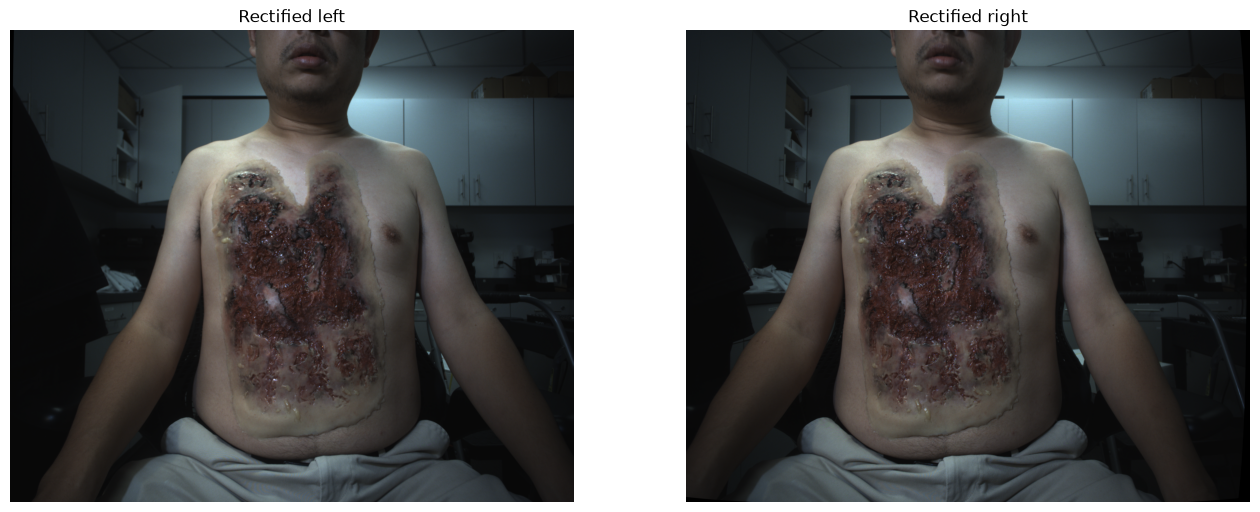

In [4]:
def json_matrix(item):
    return np.asarray(item['data'], dtype=np.float64).reshape(item['rows'], item['cols'])

def load_and_rectify(left_path, right_path, calibration_path):
    # imageio 按 RGB 读取；cv2.remap 仅重映射像素位置，不改变通道顺序。
    raw_left, raw_right = iio.imread(left_path), iio.imread(right_path)
    if raw_left.ndim != 3 or raw_left.shape[2] != 3 or raw_right.shape != raw_left.shape:
        raise ValueError(f'左右图必须是同尺寸 RGB，实际为 {raw_left.shape} / {raw_right.shape}')
    height, width = raw_left.shape[:2]
    if (width, height) != (EXPECTED_WIDTH, EXPECTED_HEIGHT):
        raise ValueError(f'期望 {EXPECTED_WIDTH}x{EXPECTED_HEIGHT}，实际为 {width}x{height}')

    calibration = json.loads(Path(calibration_path).read_text())
    K1, K2 = json_matrix(calibration['left_camera_matrix']), json_matrix(calibration['right_camera_matrix'])
    D1, D2 = json_matrix(calibration['left_distortion']), json_matrix(calibration['right_distortion'])
    R, T = json_matrix(calibration['right_to_left_rotation']), json_matrix(calibration['right_to_left_translation'])
    R1, R2, P1, P2, _, _, _ = cv2.stereoRectify(
        K1, D1, K2, D2, (width, height), R, T, flags=cv2.CALIB_ZERO_DISPARITY
    )
    left_map = cv2.initUndistortRectifyMap(K1, D1, R1, P1, (width, height), cv2.CV_32FC1)
    right_map = cv2.initUndistortRectifyMap(K2, D2, R2, P2, (width, height), cv2.CV_32FC1)
    rectified_left = cv2.remap(raw_left, *left_map, cv2.INTER_LINEAR)
    rectified_right = cv2.remap(raw_right, *right_map, cv2.INTER_LINEAR)
    rectified_K = P1[:, :3].astype(np.float32)
    baseline_m = abs(float(P2[0, 3] / P2[0, 0]))
    if baseline_m <= 0:
        raise RuntimeError(f'无效 baseline: {baseline_m}')
    return raw_left, raw_right, rectified_left, rectified_right, rectified_K, baseline_m, left_map

raw_left, raw_right, rectified_left, rectified_right, rectified_K, baseline_m, left_map = load_and_rectify(
    LEFT_PATH, RIGHT_PATH, CALIBRATION_PATH
)
print(f'Rectified: {rectified_left.shape[1]}x{rectified_left.shape[0]}, fx={rectified_K[0,0]:.2f}, baseline={baseline_m:.6f} m')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for axis, image, title in zip(axes, (rectified_left, rectified_right), ('Rectified left', 'Rectified right')):
    axis.imshow(image); axis.set_title(title); axis.axis('off')
plt.show()

In [ ]:
# left_mask.png 与原始 left.png 对齐；必须使用相同的左图 map 做最近邻重映射。
raw_left_mask = iio.imread(LEFT_MASK_PATH)
if raw_left_mask.ndim == 3:
    raw_left_mask = cv2.cvtColor(raw_left_mask[..., :3], cv2.COLOR_RGB2GRAY)
if raw_left_mask.ndim != 2 or raw_left_mask.shape != raw_left.shape[:2]:
    raise ValueError(f'left_mask.png 必须与 left.png 对齐，实际为 {raw_left_mask.shape} / {raw_left.shape[:2]}')
raw_left_mask = (raw_left_mask > 0).astype(np.uint8)
rectified_left_mask = cv2.remap(
    raw_left_mask, *left_map, cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0
) > 0
print(f'Mask: {rectified_left_mask.sum():,} / {rectified_left_mask.size:,} rectified pixels selected')
masked_preview = rectified_left.copy()
masked_preview[~rectified_left_mask] = 0
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
for axis, image, title, cmap in zip(
    axes, (rectified_left, rectified_left_mask, masked_preview),
    ('Rectified left', 'Rectified left mask', 'Selected rectified left'),
    (None, 'gray', None),
):
    axis.imshow(image, cmap=cmap); axis.set_title(title); axis.axis('off')
plt.show()

## 5. 高分辨率 inference：时间与 GPU memory

2448×2048 会先由 `InputPadder` 左右各补 8 px，模型实际输入为 2464×2048。`HIERA=1` 先在一半分辨率推理，再以其视差初始化全分辨率精修。计时仅包含模型推理和 GPU 同步，不含图像读取、rectification 和点云处理。

In [5]:
VALID_ITERS = 32
HIERA = 1
WARMUP_RUNS = 1  # 需要 benchmark 时可设为 1；warmup 不计入时间。

@torch.inference_mode()
def infer_disparity(model, left_rgb, right_rgb, valid_iters, hiera):
    height, width = left_rgb.shape[:2]
    left = torch.from_numpy(np.ascontiguousarray(left_rgb)).to(DEVICE, dtype=torch.float32).permute(2, 0, 1)[None]
    right = torch.from_numpy(np.ascontiguousarray(right_rgb)).to(DEVICE, dtype=torch.float32).permute(2, 0, 1)[None]
    padder = InputPadder(left.shape, divis_by=32, force_square=False)
    left, right = padder.pad(left, right)
    if hiera:
        disp = model.run_hierachical(left, right, iters=valid_iters, test_mode=True, small_ratio=0.5)
    else:
        disp = model.forward(left, right, iters=valid_iters, test_mode=True)
    disp = padder.unpad(disp.float())
    return disp.squeeze().cpu().numpy().reshape(height, width)

for _ in range(WARMUP_RUNS):
    _ = infer_disparity(model, rectified_left, rectified_right, VALID_ITERS, HIERA)
torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats(DEVICE)
memory_before = gpu_memory_mib()
started_at = time.perf_counter()
disparity = infer_disparity(model, rectified_left, rectified_right, VALID_ITERS, HIERA)
torch.cuda.synchronize()
inference_seconds = time.perf_counter() - started_at
memory_after = gpu_memory_mib()

print(f'Inference: {inference_seconds:.3f} s | hiera={HIERA} | valid_iters={VALID_ITERS}')
print('GPU before:', {k: f'{v:.1f} MiB' for k, v in memory_before.items()})
print('GPU after: ', {k: f'{v:.1f} MiB' for k, v in memory_after.items()})
print(f'Disparity: {disparity.shape}, min={np.nanmin(disparity):.3f}, max={np.nanmax(disparity):.3f}')

/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/foundation_stereo.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precision):
/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/submodule.py:390: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/geometry.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/liu4000/Desktop/FS_realsense/FoundationStereo/core/foundation_stereo.py:245: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.args.mixed_precisio

Inference: 8.418 s | hiera=1 | valid_iters=32
GPU before: {'allocated': '1463.9 MiB', 'reserved': '15786.0 MiB', 'peak_allocated': '1463.9 MiB', 'peak_reserved': '15786.0 MiB'}
GPU after:  {'allocated': '1463.9 MiB', 'reserved': '15786.0 MiB', 'peak_allocated': '12374.1 MiB', 'peak_reserved': '15786.0 MiB'}
Disparity: (2048, 2448), min=0.338, max=254.642


## 6. remove_invisible、深度、点云保存与去噪

等价于 `run_demo.py` 中的 `remove_invisible=1`、`get_pc=1`、`denoise_cloud=1`。深度先在 rectified 坐标中计算，再用 `left_mask.png` 选出的区域筛选。仅在当前数据目录保存 `cloud_masked.ply`（或去噪后的 `cloud_masked_denoise.ply`）；不会打开 Open3D 窗口。

In [6]:
REMOVE_INVISIBLE, GET_PC, DENOISE_CLOUD = True, True, False
USE_LEFT_MASK = True
# 仅保留相机前方 1 m 内的点。
Z_FAR_M = 1.0
DENOISE_NB_POINTS, DENOISE_RADIUS_M = 30, 0.03

disparity_for_depth = disparity.astype(np.float32, copy=True)
invalid = ~np.isfinite(disparity_for_depth) | (disparity_for_depth <= 0)
if REMOVE_INVISIBLE:
    xx = np.arange(disparity.shape[1])[None, :]
    invalid |= (xx - disparity_for_depth) < 0
disparity_for_depth[invalid] = np.inf
depth_m = rectified_K[0, 0] * baseline_m / disparity_for_depth
depth_m[~np.isfinite(depth_m) | (depth_m <= 0) | (depth_m > Z_FAR_M)] = 0
if USE_LEFT_MASK:
    depth_m[~rectified_left_mask] = 0

if GET_PC:
    xyz_map = depth2xyzmap(depth_m, rectified_K)
    point_cloud = toOpen3dCloud(xyz_map.reshape(-1, 3), rectified_left.reshape(-1, 3))
    points = np.asarray(point_cloud.points)
    point_cloud = point_cloud.select_by_index(np.flatnonzero((points[:, 2] > 0) & (points[:, 2] <= Z_FAR_M)))
    if DENOISE_CLOUD:
        point_cloud, _ = point_cloud.remove_radius_outlier(
            nb_points=DENOISE_NB_POINTS, radius=DENOISE_RADIUS_M
        )
        point_cloud_path = POINT_CLOUD_DIR / 'cloud_masked_denoise.ply'
    else:
        point_cloud_path = POINT_CLOUD_DIR / 'cloud_masked.ply'
    o3d.io.write_point_cloud(str(point_cloud_path), point_cloud)
    print(f'Point cloud points: {len(point_cloud.points):,}')
    print('Saved:', point_cloud_path)
print('Open3D visualization intentionally disabled.')

Point cloud points: 3,012,932
Saved: /home/liu4000/Desktop/FS_realsense/FoundationStereo/output/fs_high_resolution/20260813_151901
Open3D visualization intentionally disabled.


## 7. 结果快速检查

In [ ]:
valid_depth = depth_m[depth_m > 0]
print(f'Valid depth: {valid_depth.size:,} / {depth_m.size:,} pixels ({100 * valid_depth.size / depth_m.size:.1f}%)')
if valid_depth.size:
    print(f'Depth range: {valid_depth.min():.3f}–{valid_depth.max():.3f} m')
disparity_vis = vis_disparity(disparity_for_depth, invalid_thres=np.inf)
plt.figure(figsize=(16, 7))
plt.imshow(np.concatenate([rectified_left, disparity_vis], axis=1))
plt.title(f'FoundationStereo disparity — {CAPTURE_DIR.name}')
plt.axis('off')
plt.show()